In [7]:
import tensorflow as tf
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Resizing
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Conv2DTranspose
from tensorflow.keras.layers import concatenate
from tensorflow.keras.layers import Layer
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
import numpy as np
import cv2

class GaussianNoiseLayer(tf.keras.layers.Layer):
    def __init__(self, stddev, training_only=True, **kwargs):
        super().__init__(**kwargs)
        self.stddev = stddev
        self.training_only = training_only
    
    def call(self, inputs, training=None):
        if self.training_only and not training:
            return inputs
        noise = tf.random.normal(tf.shape(inputs), mean=0.0, stddev=self.stddev)
        return inputs + noise
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'stddev': self.stddev,
            'training_only': self.training_only
        })
        return config
    
class GaussianBlur(Layer):
    def __init__(self, kernel_size=5, sigma=1.0, **kwargs):
        super(GaussianBlur, self).__init__(**kwargs)
        self.kernel_size = kernel_size
        self.sigma = sigma

    def build(self, input_shape):
        ax = tf.range(-self.kernel_size // 2 + 1, self.kernel_size // 2 + 1, dtype=tf.float32)
        xx, yy = tf.meshgrid(ax, ax)
        kernel = tf.exp(-(xx**2 + yy**2) / (2. * self.sigma**2))
        kernel = kernel / tf.reduce_sum(kernel)
        kernel = tf.expand_dims(kernel, axis=-1)
        kernel = tf.expand_dims(kernel, axis=-1)
        kernel = tf.repeat(kernel, input_shape[-1], axis=-1)
        self.kernel = tf.Variable(kernel, trainable=False)

    def call(self, x):
        return tf.nn.depthwise_conv2d(x, self.kernel, strides=[1, 1, 1, 1], padding='SAME')

class WeightNoiseLayer(tf.keras.layers.Layer):
    def __init__(self, stddev, **kwargs):
        super().__init__(**kwargs)
        self.stddev = stddev
    
    def call(self, inputs):
        noise = tf.random.normal(tf.shape(inputs), mean=0.0, stddev=self.stddev)
        return inputs + noise
    
    def get_config(self):
        config = super().get_config()
        config.update({'stddev': self.stddev})
        return config

class MixupLayer(tf.keras.layers.Layer):
    def __init__(self, alpha=0.2, **kwargs):
        super().__init__(**kwargs)
        self.alpha = alpha
    
    def call(self, inputs, training=None):
        if not training:
            return inputs
        
        batch_size = tf.shape(inputs)[0]
        indices = tf.random.shuffle(tf.range(batch_size))
        shuffled_inputs = tf.gather(inputs, indices)
        
        # Generate lambda from uniform distribution (approximating Beta)
        lam = tf.random.uniform([], 0, self.alpha)
        mixed_inputs = lam * inputs + (1 - lam) * shuffled_inputs
        
        return mixed_inputs
    
    def get_config(self):
        config = super().get_config()
        config.update({'alpha': self.alpha})
        return config

class PrivacyPreservingUNet:
    def __init__(self, 
                 input_size=(None, None, 1), 
                 target_size=(128, 128), 
                 num_classes=4,
                 privacy_config=None):
        """
        Privacy-preserving U-Net using only native TensorFlow/Keras
        
        Args:
            privacy_config: dict with privacy settings
                - 'gradient_noise': float, noise level for gradient perturbation (default: 0.1)
                - 'gradient_clipping': float, gradient clipping value (default: 1.0)
                - 'input_noise': float, input perturbation level (default: 0.01)
                - 'weight_noise': float, weight noise injection (default: 0.001)
                - 'privacy_dropout': float, enhanced dropout for privacy (default: 0.2)
                - 'label_smoothing': float, label smoothing for privacy (default: 0.1)
                - 'mixup_alpha': float, mixup augmentation parameter (default: 0.2)
                - 'feature_noise': bool, add noise to intermediate features
        """
        self.input_size = input_size
        self.target_size = target_size
        self.num_classes = num_classes
        
        # Default privacy configuration
        self.privacy_config = {
            'gradient_noise': 0.1,
            'gradient_clipping': 1.0,
            'input_noise': 0.01,
            'weight_noise': 0.001,
            'privacy_dropout': 0.2,
            'label_smoothing': 0.1,
            'mixup_alpha': 0.2,
            'feature_noise': True
        }
        
        if privacy_config:
            self.privacy_config.update(privacy_config)
    
    def add_gaussian_noise_layer(self, x, noise_stddev=0.01, training_only=True, name="noise"):
        """Add Gaussian noise layer for privacy protection"""
        return GaussianNoiseLayer(stddev=noise_stddev, training_only=training_only, name=name)(x)
    
    def privacy_aware_conv_block(self, x, filters, block_name, dropout_rate=0.1, add_feature_noise=False):
        """Convolutional block with privacy-enhancing modifications"""
        # First convolution
        conv = Conv2D(filters, (3, 3), activation='relu', padding='same', 
                     kernel_initializer='he_normal', 
                     kernel_regularizer=tf.keras.regularizers.l2(0.001),
                     name=f"{block_name}_conv1")(x)
        
        # Add feature noise for privacy
        if add_feature_noise and self.privacy_config.get('feature_noise', False):
            conv = self.add_gaussian_noise_layer(
                conv, noise_stddev=0.005, name=f"{block_name}_feature_noise1"
            )
        
        conv = BatchNormalization(name=f"{block_name}_bn1")(conv)
        
        # Second convolution
        conv = Conv2D(filters, (3, 3), activation='relu', padding='same', 
                     kernel_initializer='he_normal',
                     kernel_regularizer=tf.keras.regularizers.l2(0.001),
                     name=f"{block_name}_conv2")(conv)
        
        if add_feature_noise and self.privacy_config.get('feature_noise', False):
            conv = self.add_gaussian_noise_layer(
                conv, noise_stddev=0.005, name=f"{block_name}_feature_noise2"
            )
        
        conv = BatchNormalization(name=f"{block_name}_bn2")(conv)
        
        # Enhanced dropout for privacy
        privacy_dropout = max(dropout_rate, self.privacy_config.get('privacy_dropout', 0.2))
        conv = Dropout(privacy_dropout, name=f"{block_name}_dropout")(conv)
        
        return conv
    
    def add_weight_noise_layer(self, x, noise_stddev=0.001, name="weight_noise"):
        """Add noise to simulate weight perturbation"""
        return WeightNoiseLayer(stddev=noise_stddev, name=name)(x)
    
    def mixup_layer(self, x, y=None, alpha=0.2, name="mixup"):
        """Mixup augmentation for privacy protection"""
        return MixupLayer(alpha=alpha, name=name)(x)

    
    def build_model(self):
        inputs = Input(self.input_size, name="input_layer")
    
        # Preprocessing
        x = tf.keras.layers.Resizing(self.target_size[0], self.target_size[1], name="resize")(inputs)
        x = tf.keras.layers.Rescaling(1./255, name="rescale")(x)
        
        # Optional Gaussian Blur (comment out if not needed)
        x = GaussianBlur(name="gaussian_blur")(x)

        # Encoder Path
        # Block 1
        c1 = Conv2D(32, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(x)
        c1 = BatchNormalization()(c1)
        c1 = Conv2D(32, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(c1)
        c1 = BatchNormalization()(c1)
        p1 = MaxPooling2D((2, 2))(c1)
        p1 = Dropout(0.1)(p1)

        # Block 2
        c2 = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(p1)
        c2 = BatchNormalization()(c2)
        c2 = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(c2)
        c2 = BatchNormalization()(c2)
        p2 = MaxPooling2D((2, 2))(c2)
        p2 = Dropout(0.2)(p2)

        # Block 3
        c3 = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(p2)
        c3 = BatchNormalization()(c3)
        c3 = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(c3)
        c3 = BatchNormalization()(c3)
        p3 = MaxPooling2D((2, 2))(c3)
        p3 = Dropout(0.3)(p3)

        # Bottleneck
        c4 = Conv2D(256, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(p3)
        c4 = BatchNormalization()(c4)
        c4 = Conv2D(256, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(c4)
        c4 = BatchNormalization()(c4)
        c4 = Dropout(0.4)(c4)

        # Decoder Path
        # Block 5
        u5 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c4)
        u5 = concatenate([u5, c3])
        c5 = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(u5)
        c5 = BatchNormalization()(c5)
        c5 = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(c5)
        c5 = BatchNormalization()(c5)
        c5 = Dropout(0.3)(c5)

        # Block 6
        u6 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c5)
        u6 = concatenate([u6, c2])
        c6 = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(u6)
        c6 = BatchNormalization()(c6)
        c6 = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(c6)
        c6 = BatchNormalization()(c6)
        c6 = Dropout(0.2)(c6)

        # Block 7
        u7 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c6)
        u7 = concatenate([u7, c1])
        c7 = Conv2D(32, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(u7)
        c7 = BatchNormalization()(c7)
        c7 = Conv2D(32, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(c7)
        c7 = BatchNormalization()(c7)
        c7 = Dropout(0.1)(c7)

        # Output layer
        outputs = Conv2D(self.num_classes, (1, 1), activation='softmax')(c7)

        model = Model(inputs, outputs, name="improved_unet")
        return model
       

# Custom optimizer with gradient noise and clipping
class PrivacyAwareOptimizer:
    def __init__(self, base_optimizer, gradient_noise_stddev=0.1, gradient_clip_value=1.0):
        self.base_optimizer = base_optimizer
        self.gradient_noise_stddev = gradient_noise_stddev
        self.gradient_clip_value = gradient_clip_value
    
    def get_optimizer(self):
        """Get optimizer with privacy-preserving modifications"""
        # Note: This is a conceptual implementation
        # In practice, you would need to implement custom training loop
        return self.base_optimizer

# Custom training function with privacy techniques
def train_with_privacy_techniques(model, train_data, val_data, privacy_config, 
                                 epochs=100, batch_size=32):
    """
    Custom training function with privacy-preserving techniques
    """

    img_train, label_train = train_data
    
    # Compile model with privacy-aware settings
    optimizer = tf.keras.optimizers.Adam(
        learning_rate=1e-4,
        clipnorm=privacy_config.get('gradient_clipping', 1.0)  # Gradient clipping
    )
    
    # Use label smoothing for privacy
    if privacy_config.get('label_smoothing', 0) > 0:
        loss = tf.keras.losses.CategoricalCrossentropy(
            label_smoothing=privacy_config['label_smoothing']
        )
    else:
        loss = 'sparse_categorical_crossentropy'
    
    model.compile(
        optimizer=optimizer,
        loss= "sparse_categorical_crossentropy",
        metrics=['accuracy', dice_coefficient_multiclass, iou_metric_multiclass]
    )
    
    # Custom callbacks for privacy
    callbacks = [
        tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5),
    ]
    
    # Add gradient noise callback (custom implementation would be needed)
    if privacy_config.get('gradient_noise', 0) > 0:
        print(f"Training with gradient noise: {privacy_config['gradient_noise']}")
        # Note: Full implementation would require custom training loop
    
    print("Privacy-preserving training configuration:")
    for key, value in privacy_config.items():
        print(f"  {key}: {value}")
    
    history = model.fit(
        img_train, label_train,
        validation_data=val_data,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
    )
    
    return history

def dice_coefficient_multiclass(y_true, y_pred, smooth=1e-6):
        """Dice coefficient for multi-class segmentation with sparse labels"""
        # Convert sparse labels to one-hot if needed
        if len(y_true.shape) != len(y_pred.shape):
            y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=tf.shape(y_pred)[-1])
            y_true = tf.cast(y_true, tf.float32)
        
        # Flatten tensors
        y_true_f = tf.reshape(y_true, [-1, tf.shape(y_true)[-1]])
        y_pred_f = tf.reshape(y_pred, [-1, tf.shape(y_pred)[-1]])
        
        intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=0)
        union = tf.reduce_sum(y_true_f, axis=0) + tf.reduce_sum(y_pred_f, axis=0)
        dice = (2. * intersection + smooth) / (union + smooth)
        
        return tf.reduce_mean(dice)

def dice_loss_multiclass(y_true, y_pred, smooth=1e-6):
    """Dice loss for multi-class segmentation"""
    return 1 - dice_coefficient_multiclass(y_true, y_pred, smooth)

def focal_loss_multiclass(gamma=2., alpha=0.25):
    """Focal loss for multi-class segmentation with sparse labels"""
    def focal_loss_fixed(y_true, y_pred):
        # Convert sparse labels to one-hot if needed
        if len(y_true.shape) != len(y_pred.shape):
            y_true_onehot = tf.one_hot(tf.cast(y_true, tf.int32), depth=tf.shape(y_pred)[-1])
            y_true_onehot = tf.cast(y_true_onehot, tf.float32)
        else:
            y_true_onehot = y_true
            
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
        
        # Calculate cross entropy
        ce = -y_true_onehot * tf.math.log(y_pred)
        
        # Calculate focal weight
        p_t = tf.where(tf.equal(y_true_onehot, 1), y_pred, 1 - y_pred)
        alpha_factor = y_true_onehot * alpha + (1 - y_true_onehot) * (1 - alpha)
        modulating_factor = tf.pow((1 - p_t), gamma)
        
        # Apply focal weight
        focal_ce = alpha_factor * modulating_factor * ce
        
        return tf.reduce_mean(tf.reduce_sum(focal_ce, axis=-1))
    
    return focal_loss_fixed

def weighted_categorical_crossentropy(class_weights):
    """Weighted categorical crossentropy for handling class imbalance"""
    def loss(y_true, y_pred):
        # Convert sparse labels to one-hot if needed
        if len(y_true.shape) != len(y_pred.shape):
            y_true_onehot = tf.one_hot(tf.cast(y_true, tf.int32), depth=tf.shape(y_pred)[-1])
            y_true_onehot = tf.cast(y_true_onehot, tf.float32)
        else:
            y_true_onehot = y_true
            
        # Apply class weights
        weights = tf.reduce_sum(class_weights * y_true_onehot, axis=-1)
        
        # Calculate categorical crossentropy
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1 - epsilon)
        loss = -tf.reduce_sum(y_true_onehot * tf.math.log(y_pred), axis=-1)
        
        return tf.reduce_mean(weights * loss)
    
    return loss

# IoU Metric for multi-class
def iou_metric_multiclass(y_true, y_pred, smooth=1e-6):
    # Convert predictions to class labels
    y_pred = tf.argmax(y_pred, axis=-1)
    y_pred = tf.cast(y_pred, tf.float32)
    y_true = tf.cast(y_true, tf.float32)

    # Flatten
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(tf.cast(y_true_f == y_pred_f, tf.float32))
    union = tf.cast(tf.size(y_true_f, out_type=tf.int32), tf.float32)

    return (intersection + smooth) / (union + smooth)


# Improved Learning Rate Scheduler
def scheduler(epoch, lr):
    if epoch < 10:
        return lr
    elif epoch < 20:
        return lr * 0.5
    else:
        return lr * 0.1

# Factory function for different privacy levels
def create_lightweight_privacy_unet(privacy_level="medium"):
    """
    Create U-Net with different privacy levels using only native TensorFlow
    """
    privacy_configs = {
        "low": {
            'input_noise': 0.005,
            'privacy_dropout': 0.15,
            'gradient_clipping': 2.0,
            'label_smoothing': 0.05,
            'feature_noise': False
        },
        "medium": {
            'gradient_noise': 0.1,
            'gradient_clipping': 1.0,
            'input_noise': 0.01,
            'weight_noise': 0.001,
            'privacy_dropout': 0.2,
            'label_smoothing': 0.1,
            'mixup_alpha': 0.2,
            'feature_noise': True
        },
        "high": {
            'gradient_noise': 0.2,
            'gradient_clipping': 0.5,
            'input_noise': 0.02,
            'weight_noise': 0.005,
            'privacy_dropout': 0.3,
            'label_smoothing': 0.15,
            'mixup_alpha': 0.3,
            'feature_noise': True
        }
    }
    
    config = privacy_configs.get(privacy_level, privacy_configs["medium"])
    
    privacy_unet = PrivacyPreservingUNet(
        input_size=(None, None, 1),
        target_size=(128, 128),
        num_classes=4,
        privacy_config=config
    )
    
    model = privacy_unet.build_model()
    
    print(f"\nPrivacy-preserving U-Net created with {privacy_level} privacy level")
    print("Privacy techniques applied:")
    for technique, value in config.items():
        if value:
            print(f"  ✓ {technique}: {value}")
    
    return model, config

def load_model():
    custom_objects = {
        # Custom layers
        'GaussianBlur': GaussianBlur,
        'GaussianNoiseLayer': GaussianNoiseLayer,
        'WeightNoiseLayer': WeightNoiseLayer,
        'MixupLayer': MixupLayer,
        
        # Custom metrics and loss functions
        'dice_coefficient_multiclass': dice_coefficient_multiclass,
        'iou_metric_multiclass': iou_metric_multiclass,
    }
    model = tf.keras.models.load_model('path_to_your_model.h5', custom_objects=custom_objects)
    return model    

# Usage example:
# model, privacy_config = create_lightweight_privacy_unet(privacy_level="medium")
# print(model.summary())
# 
# # Train with privacy techniques
# history = train_with_privacy_techniques(
#     model, train_data, val_data, privacy_config, epochs=50
# )

2025-06-22 22:50:13.695188: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-22 22:50:13.752240: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750612813.780988  177090 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750612813.789782  177090 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1750612813.831896  177090 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [8]:
import os

def load_images_label_pairs(images , labels, image_dir, label_dir, step=1, step_size=1000, add_noise=False):
    image_files = sorted(os.listdir(image_dir))  # Sort to maintain consistency
    label_files = sorted(os.listdir(label_dir))

    images =[]
    labels=[]

    # currupted_images = [2355, 2365, 2366]
    print("Images count: " + str(len(image_files)))
    for img, label in zip(image_files[step * step_size: (step + 1) * step_size], label_files[step * step_size: (step + 1) * step_size]):
        # print("Processing image: " + img + " with label: " + label)
        img_path = os.path.join(image_dir, img)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Adjust if images are colored
        if add_noise == True:
            noise = np.random.normal(loc=0, scale=10, size=img.shape).astype(np.float32)
            img = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)
        img = cv2.resize(img, (128, 128))
        images.append(img)


        label_path = os.path.join(label_dir, label)
        label = np.load(label_path)
        label = cv2.resize(label, (128, 128))  # Resize to match the image size
        labels.append(label)

    # return images, labels
    return np.array(images), np.array(labels)

In [9]:
image_dir_path = '/home/yasas/GazeEstimation/openEDS/openEDS/train/images'
label_dir_path = '/home/yasas/GazeEstimation/openEDS/openEDS/train/labels'


images = []
labels = []

images, labels = load_images_label_pairs(images , labels , image_dir_path, label_dir_path, step=0, step_size=10000, add_noise=True)

Images count: 27431


In [10]:
from sklearn.model_selection import train_test_split

model, config = create_lightweight_privacy_unet(privacy_level="medium")

img_train, img_test, label_train, label_test = train_test_split(images, labels, test_size=0.2, random_state=42)

train_with_privacy_techniques(model=model, 
                              train_data=(img_train, label_train), 
                              val_data=(img_test, label_test), 
                              privacy_config=config, 
                              epochs=50, 
                              batch_size=8)

model.save('privacy_preserving_unet.h5')

custom_objects = {
        # Custom layers
        'GaussianBlur': GaussianBlur,
        'GaussianNoiseLayer': GaussianNoiseLayer,
        'WeightNoiseLayer': WeightNoiseLayer,
        'MixupLayer': MixupLayer,
        
        # Custom metrics and loss functions
        'dice_coefficient_multiclass': dice_coefficient_multiclass,
        'iou_metric_multiclass': iou_metric_multiclass,
    }

model = tf.keras.models.load_model(
            'privacy_preserving_unet.h5',
            custom_objects=custom_objects
        )

I0000 00:00:1750613065.208317  177090 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3586 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6



Privacy-preserving U-Net created with medium privacy level
Privacy techniques applied:
  ✓ gradient_noise: 0.1
  ✓ gradient_clipping: 1.0
  ✓ input_noise: 0.01
  ✓ weight_noise: 0.001
  ✓ privacy_dropout: 0.2
  ✓ label_smoothing: 0.1
  ✓ mixup_alpha: 0.2
  ✓ feature_noise: True
Training with gradient noise: 0.1
Privacy-preserving training configuration:
  gradient_noise: 0.1
  gradient_clipping: 1.0
  input_noise: 0.01
  weight_noise: 0.001
  privacy_dropout: 0.2
  label_smoothing: 0.1
  mixup_alpha: 0.2
  feature_noise: True
Epoch 1/50


I0000 00:00:1750613076.619493  183605 service.cc:152] XLA service 0x7dd708002840 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1750613076.619625  183605 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2025-06-22 22:54:36.850555: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1750613078.502016  183605 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1750613093.147782  183605 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 63s 37ms/step - accuracy: 0.8256 - dice_coefficient_multiclass: 0.4395 - iou_metric_multiclass: 0.8256 - loss: 0.6434 - val_accuracy: 0.9851 - val_dice_coefficient_multiclass: 0.8293 - val_iou_metric_multiclass: 0.9851 - val_loss: 0.0651 - learning_rate: 1.0000e-04
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 35s 35ms/step - accuracy: 0.9828 - dice_coefficient_multiclass: 0.7877 - iou_metric_multiclass: 0.9828 - loss: 0.0785 - val_accuracy: 0.9886 - val_dice_coefficient_multiclass: 0.8931 - val_iou_metric_multiclass: 0.9886 - val_loss: 0.0374 - learning_rate: 1.0000e-04
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 35s 35ms/step - accuracy: 0.9861 - dice_coefficient_multiclass: 0.8708 - iou_metric_multiclass: 0.9861 - loss: 0.0473 - val_accuracy: 0.9897 - val_dice_coefficient_multiclass: 0.9253 - val_iou_metric_multiclass: 0.9897 - val_loss: 0.0309 - learning_rate: 1.0000e-04
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 36s 36ms/step - accuracy: 0.9879 - dice_coeff

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


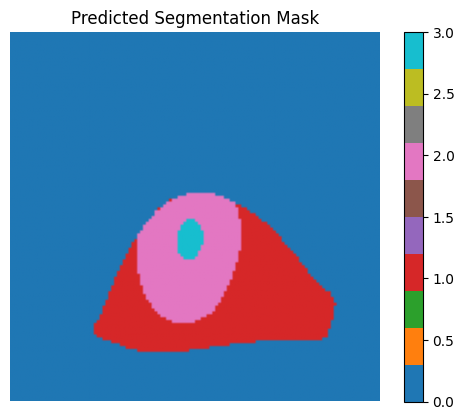

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

image_path = '/home/yasas/GazeEstimation/openEDS/openEDS/train/images/008110.png'

image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

img_input = np.expand_dims(image, axis=(0, -1))  # e.g., (1, 240, 320, 1)

# Step 4: Predict with the model
pred = model.predict(img_input)  # Output shape: (1, 128, 128, 4) due to resizing inside model

# Step 5: Convert softmax to class labels
predicted_mask = np.argmax(pred, axis=-1)[0]  # Shape: (128, 128)

plt.imshow(predicted_mask, cmap='tab10', vmin=0, vmax=3)
plt.title("Predicted Segmentation Mask")
plt.colorbar()
plt.axis('off')
plt.show()

plt.tight_layout()